Aperçu de pokemon.csv :
   #           Name Type 1  Type 2  HP  Attack  Defense  Sp. Atk  Sp. Def  \
0  1      Bulbasaur  Grass  Poison  45      49       49       65       65   
1  2        Ivysaur  Grass  Poison  60      62       63       80       80   
2  3       Venusaur  Grass  Poison  80      82       83      100      100   
3  4  Mega Venusaur  Grass  Poison  80     100      123      122      120   
4  5     Charmander   Fire     NaN  39      52       43       60       50   

   Speed  Generation  Legendary  
0     45           1      False  
1     60           1      False  
2     80           1      False  
3     80           1      False  
4     65           1      False  

Aperçu de combats.csv :
   First_pokemon  Second_pokemon  Winner
0            266             298     298
1            702             701     701
2            191             668     668
3            237             683     683
4            151             231     151

Valeurs manquantes après nettoyage :


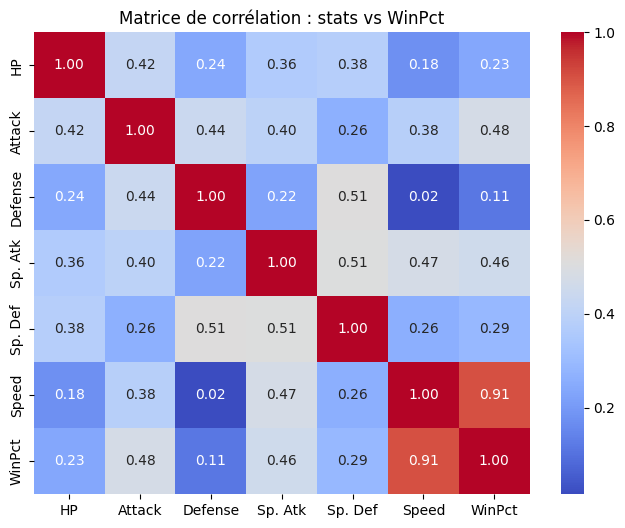

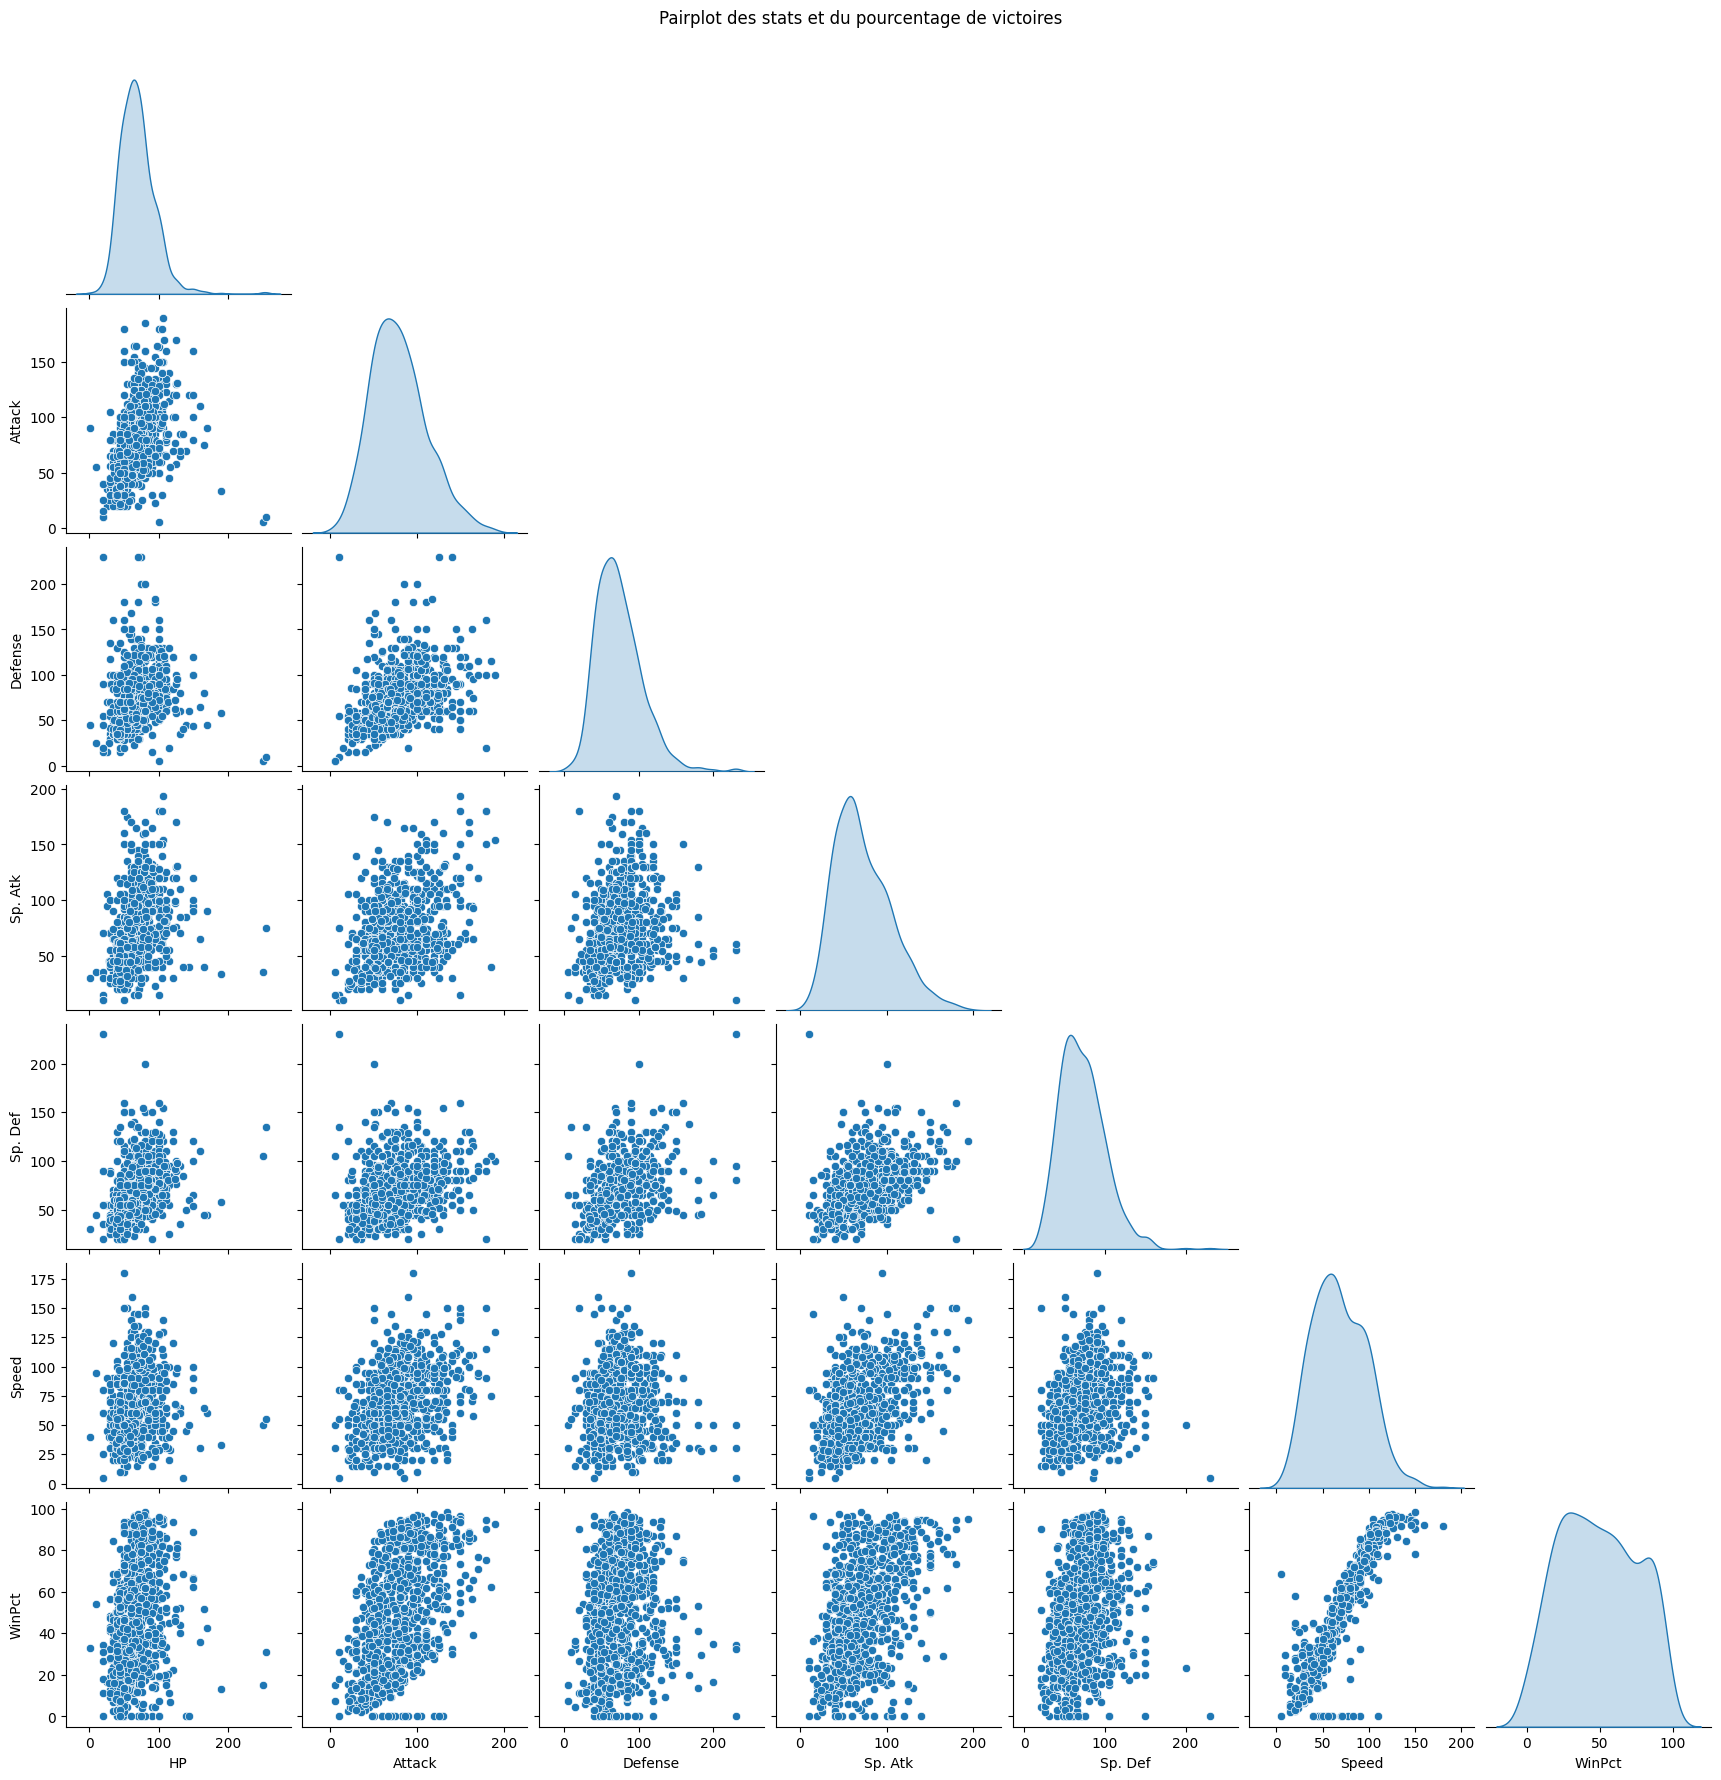


Top 10 des Pokémon par WinPct :
       #                      Name     WinPct   HP  Attack  Defense  Speed
154  155           Mega Aerodactyl  98.449612   80     135       85    150
512  513                   Weavile  97.478992   70     120       65    125
703  704    Tornadus Therian Forme  96.800000   79     100       80    121
19    20             Mega Beedrill  96.638655   65     150       40    145
153  154                Aerodactyl  96.453901   80     105       65    130
476  477              Mega Lopunny  96.124031   65     136       94    135
726  727                  Greninja  96.062992   72      95       67    122
716  717  Meloetta Pirouette Forme  95.934959  100     128       90    128
164  165             Mega Mewtwo Y  95.200000  106     150       70    140
349  350             Mega Sharpedo  95.000000   70     140       70    105

Moyennes des stats pour le top 10 :
HP          78.7
Attack     125.9
Defense     72.6
Speed      130.1
dtype: float64


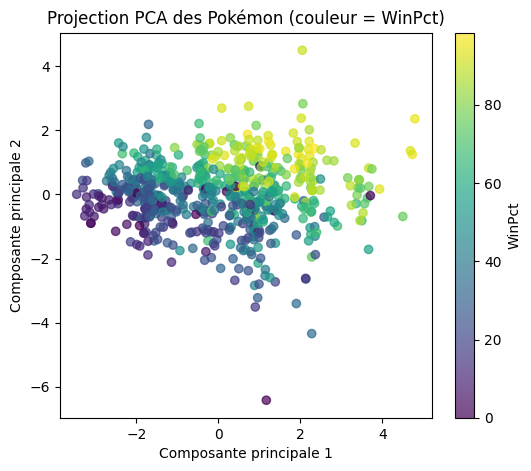

Linear Regression    MAE = 6.4915
Random Forest        MAE = 5.7424
XGBoost              MAE = 6.5788


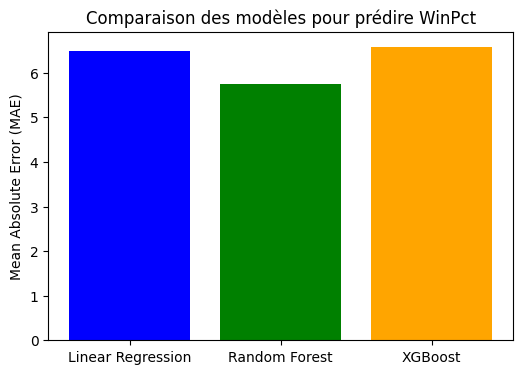


Meilleur modèle : Random Forest avec MAE = 5.7424


In [3]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# 1. CHARGEMENT DES DONNÉES
pokemon = pd.read_csv('pokemon.csv')
combats = pd.read_csv('combats.csv')

print("Aperçu de pokemon.csv :")
print(pokemon.head())
print("\nAperçu de combats.csv :")
print(combats.head())

# 2. NETTOYAGE DES DONNÉES

# Remplacer le nom manquant du Pokémon #62 (Primeape)
pokemon.loc[pokemon['#'] == 62, 'Name'] = 'Primeape'

# Remplacer les NaN dans 'Type 2' par "None"
pokemon['Type 2'] = pokemon['Type 2'].fillna('None')

# Vérification des valeurs manquantes restantes
print("\nValeurs manquantes après nettoyage :")
print(pokemon.isnull().sum())

# 3. CALCUL DU POURCENTAGE DE VICTOIRES PAR POKÉMON

# Compter le nombre de combats où le Pokémon est le gagnant
wins = combats['Winner'].value_counts().reset_index()
wins.columns = ['First', 'wins']

# Compter le nombre total de combats où le Pokémon apparaît (en tant que First ou Second)
total_battles = pd.concat([combats['First_pokemon'], combats['Second_pokemon']]).value_counts().reset_index()
total_battles.columns = ['First', 'total']

# Fusionner les deux tableaux pour obtenir wins et total
win_percent = wins.merge(total_battles, on='First', how='right').fillna(0)
win_percent['win_percentage'] = (win_percent['wins'] / win_percent['total']) * 100
win_percent = win_percent.rename(columns={'First': '#', 'win_percentage': 'WinPct'})

# Ajouter la colonne WinPct au DataFrame pokemon
pokemon = pokemon.merge(win_percent[['#', 'WinPct']], on='#', how='left')
pokemon['WinPct'] = pokemon['WinPct'].fillna(0)

# 4. EXPLORATION ET VISUALISATIONS

# Matrice de corrélation entre les stats et le pourcentage de victoires
stats_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'WinPct']
corr_matrix = pokemon[stats_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matrice de corrélation : stats vs WinPct')
plt.show()

# Pairplot pour visualiser les relations entre stats et WinPct
sns.pairplot(pokemon[stats_cols], diag_kind='kde', corner=True)
plt.suptitle('Pairplot des stats et du pourcentage de victoires', y=1.02)
plt.show()

# Top 10 des Pokémon par pourcentage de victoires
top10 = pokemon.nlargest(10, 'WinPct')[['#', 'Name', 'WinPct', 'HP', 'Attack', 'Defense', 'Speed']]
print("\nTop 10 des Pokémon par WinPct :")
print(top10)

# Analyse des stats des top 10 (moyennes)
print("\nMoyennes des stats pour le top 10 :")
print(top10[['HP', 'Attack', 'Defense', 'Speed']].mean())

# 5. PRÉPARATION POUR LE MACHINE LEARNING

# Sélection des features pertinentes (variables explicatives)
features = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
X = pokemon[features].copy()
y = pokemon['WinPct']

# Supprimer les lignes où WinPct est NaN (normalement déjà remplacé)
valid = ~y.isna()
X = X[valid]
y = y[valid]

# Division en ensembles d'entraînement (80%) et de test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardisation des features (nécessaire pour certains modèles)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# (Optionnel) Réduction de dimension avec PCA pour visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, cmap='viridis', alpha=0.7)
plt.colorbar(label='WinPct')
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.title('Projection PCA des Pokémon (couleur = WinPct)')
plt.show()

# 6. ENTRAÎNEMENT ET COMPARAISON DES MODÈLES

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, eval_metric='mae')
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    results[name] = mae
    print(f"{name:20} MAE = {mae:.4f}")

# Comparaison graphique
plt.figure(figsize=(6,4))
plt.bar(results.keys(), results.values(), color=['blue', 'green', 'orange'])
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Comparaison des modèles pour prédire WinPct')
plt.show()

# Meilleur modèle (celui avec le plus petit MAE)
best_model = min(results, key=results.get)
print(f"\nMeilleur modèle : {best_model} avec MAE = {results[best_model]:.4f}")